# Análisis de adopción y uso de IA en empresas

## Fuente y alcance del dataset

**Fuente:** [Kaggle — Global AI Tool Adoption Across Industries](https://www.kaggle.com/datasets/tfisthis/global-ai-tool-adoption-across-industries).

El archivo contiene 145.000 registros y 9 variables: país, industria, herramienta de IA, tasa de adopción, usuarios activos diarios, año, feedback de usuario, grupo etario y tamaño de empresa. El período observado es 2023–2024.

Cada fila se interpreta como una observación de adopción y uso. Como la base no incluye un identificador único de empresa, no permite contar compañías únicas ni seguir a la misma organización entre años.

In [42]:
import pandas as pd

df = pd.read_csv(r"dataset\raw\ai_adoption_dataset.csv")

# Visión General
print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}\n")

print("=== TIPOS DE DATOS Y NULOS ===")
print(df.info())
print("\n")

# Conteo de Valores Faltantes
nulos = df.isnull().sum()
print("=== VALORES FALTANTES ===")
print(nulos[nulos > 0])
print("\n")

# Valores Duplicados
print("=== DUPLICADOS ===")
print(f"Filas exactamente duplicadas: {df.duplicated().sum()}\n")

# Resumen Estadístico 
print("=== RESUMEN VARIABLES NUMÉRICAS ===")
print(df.describe().round(2))
print("\n")

print("=== VALORES ÚNICOS EN CATEGÓRICAS CLAVE ===")
cols_categoricas = ['industry', 'ai_tool', 'company_size', 'year']
for col in cols_categoricas:
    print(f"--- {col.upper()} ---")
    print(df[col].unique())
    print("\n")

=== FORMA DEL DATASET ===
Filas: 145000
Columnas: 9

=== TIPOS DE DATOS Y NULOS ===
<class 'pandas.DataFrame'>
RangeIndex: 145000 entries, 0 to 144999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   country             145000 non-null  str    
 1   industry            145000 non-null  str    
 2   ai_tool             145000 non-null  str    
 3   adoption_rate       145000 non-null  float64
 4   daily_active_users  145000 non-null  int64  
 5   year                145000 non-null  int64  
 6   user_feedback       145000 non-null  str    
 7   age_group           145000 non-null  str    
 8   company_size        145000 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 35.7 MB
None


=== VALORES FALTANTES ===
Series([], dtype: int64)


=== DUPLICADOS ===
Filas exactamente duplicadas: 0

=== RESUMEN VARIABLES NUMÉRICAS ===
       adoption_rate  daily_active_users       year
count   

In [43]:
# Preparación de variables para el análisis
df_clean = pd.read_csv(r"dataset\clean\ai_adoption_dataset.csv")

tool_mapping = {
    'ChatGPT': 'Generación de Texto',
    'Claude': 'Generación de Texto',
    'Bard': 'Generación de Texto',
    'Midjourney': 'Generación de Imagen',
    'Stable Diffusion': 'Generación de Imagen',
}

company_size_order = ['Startup', 'SME', 'Enterprise']
tool_category_order = ['Generación de Texto', 'Generación de Imagen']

df_clean['tool_category'] = df_clean['ai_tool'].map(tool_mapping)

unknown_tools = df_clean.loc[
    df_clean['tool_category'].isna(), 'ai_tool'
].unique()

if len(unknown_tools) > 0:
    raise ValueError(f'Herramientas sin categoría: {unknown_tools.tolist()}')

df_clean['year'] = pd.to_numeric(df_clean['year'], errors='raise')
df_clean['company_size'] = pd.Categorical(
    df_clean['company_size'],
    categories=company_size_order,
    ordered=True,
)
df_clean['tool_category'] = pd.Categorical(
    df_clean['tool_category'],
    categories=tool_category_order,
    ordered=True,
)

print("=== DISTRIBUCIÓN POR CATEGORÍA DE IA ===")
print(df_clean['tool_category'].value_counts())
print("\n=== TIPOS DE DATOS PARA EL ANÁLISIS ===")
print(df_clean[['year', 'tool_category']].dtypes)

=== DISTRIBUCIÓN POR CATEGORÍA DE IA ===
tool_category
Generación de Texto     79850
Generación de Imagen    65150
Name: count, dtype: int64

=== TIPOS DE DATOS PARA EL ANÁLISIS ===
year                int64
tool_category    category
dtype: object


=== EDA 1: Tasa de adopción promedio por tamaño de empresa ===
               mean  median  count
company_size                      
Startup       50.04   49.98  48601
SME           49.74   49.62  48120
Enterprise    49.84   49.68  48279


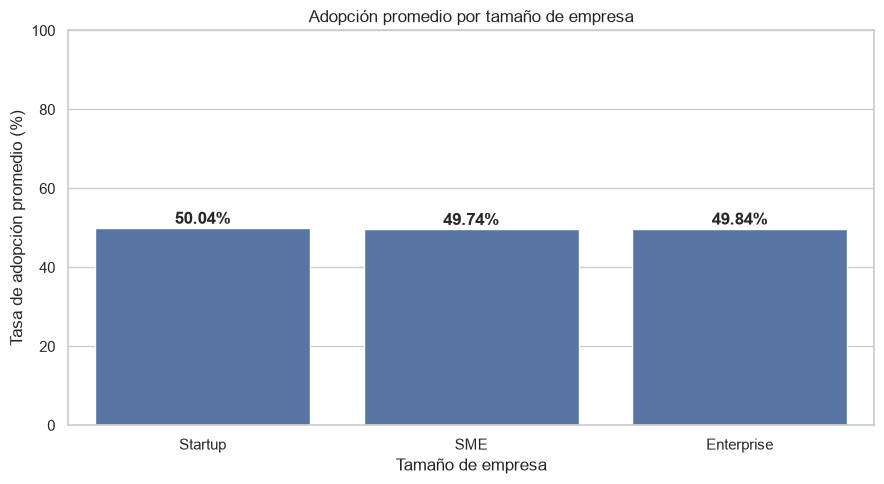


--------------------------------------------------

=== EDA 2: Adopcion promedio de IA de texto VS IA de imagen por industria ===
tool_category   Generación de Texto  Generación de Imagen  \
industry                                                    
Transportation                50.10                 49.52   
Finance                       50.22                 49.65   
Healthcare                    49.99                 49.72   
Agriculture                   50.42                 50.21   
Manufacturing                 49.54                 49.62   
Retail                        49.56                 49.66   
Technology                    49.95                 50.11   
Education                     49.57                 50.06   

tool_category   Diferencia (Texto - Imagen)  
industry                                     
Transportation                         0.58  
Finance                                0.57  
Healthcare                             0.27  
Agriculture                 

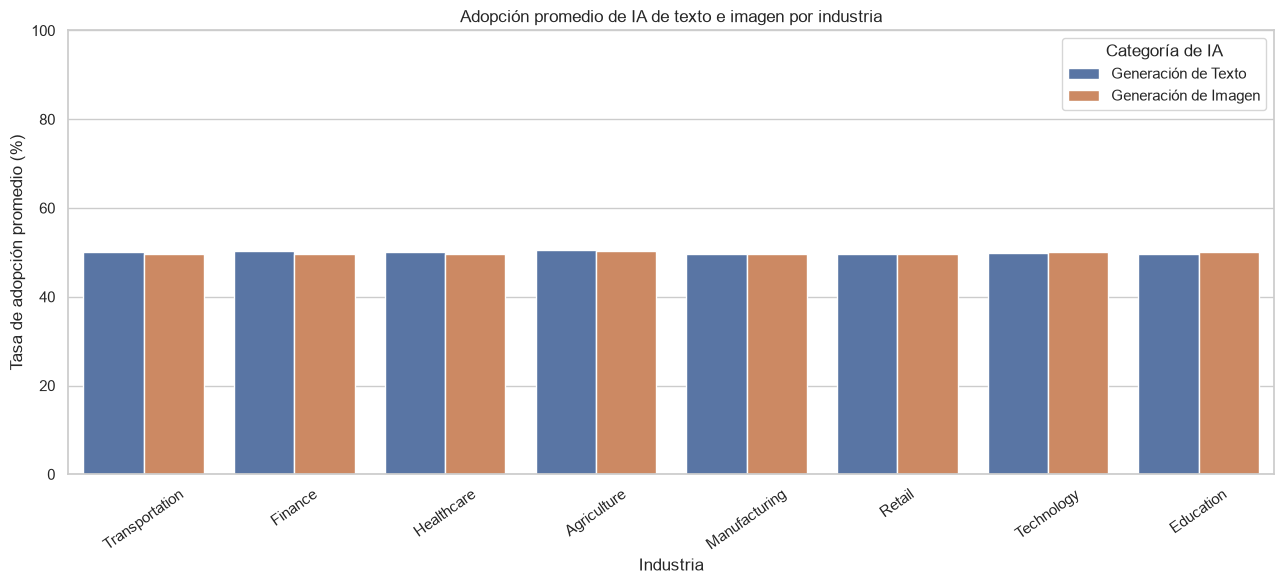

In [44]:

import matplotlib.pyplot as plt
# ==========================================
# EDA 1: Adopción vs. Tamaño de Empresa
# ==========================================
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')

company_size_order = ['Startup', 'SME', 'Enterprise']

print("=== EDA 1: Tasa de adopción promedio por tamaño de empresa ===")
eda_1 = (
    df_clean.groupby('company_size', observed=True)['adoption_rate']
    .agg(['mean', 'median', 'count'])
    .reindex(company_size_order)
    .round(2)
)
print(eda_1)

eda_1_plot = eda_1.reset_index()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=eda_1_plot,
    x='company_size',
    y='mean',
    order=company_size_order,
    color='#4C72B0',
    errorbar=None,
)

for index, value in enumerate(eda_1_plot['mean']):
    ax.text(index, value + 1, f'{value:.2f}%', ha='center', fontweight='bold')

ax.set_title('Adopción promedio por tamaño de empresa')
ax.set_xlabel('Tamaño de empresa')
ax.set_ylabel('Tasa de adopción promedio (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()
print("\n" + "-"*50 + "\n")

# ==========================================
# EDA 2: Texto vs. Imagen por Industria
# ==========================================
print("=== EDA 2: Adopcion promedio de IA de texto VS IA de imagen por industria ===")
# ¿Qué queremos averiguar?: ¿ChatGPT/Texto es transversal a todas las industrias y Midjourney/Imagen tiene nichos específicos? (Hipótesis 2)
eda_2 = pd.pivot_table(
    df_clean, 
    values='adoption_rate', 
    index='industry', 
    columns='tool_category', 
    aggfunc='mean'
).round(2)

# Calculamos la diferencia entre ambos para ver que tecnología predomina en cada rubro
eda_2['Diferencia (Texto - Imagen)'] = eda_2['Generación de Texto'] - eda_2['Generación de Imagen']
eda_2 = eda_2.sort_values(by='Diferencia (Texto - Imagen)', ascending=False)
print(eda_2)

eda_2_plot = (
    df_clean.groupby(['industry', 'tool_category'], observed=True)['adoption_rate']
    .mean()
    .reset_index()
)

plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=eda_2_plot,
    x='industry',
    y='adoption_rate',
    hue='tool_category',
    order=eda_2.index.tolist(),
    hue_order=tool_category_order,
    errorbar=None,
)

ax.set_title('Adopción promedio de IA de texto e imagen por industria')
ax.set_xlabel('Industria')
ax.set_ylabel('Tasa de adopción promedio (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Categoría de IA')
plt.tight_layout()
plt.show()

=== EDA 3: Evolución anual ===
   year  adoption_rate_mean  dau_mean  sample_size  adoption_yoy_pct  \
0  2023               50.02   5034.83        43048               NaN   
1  2024               49.81   5041.19       101952             -0.42   

   dau_yoy_pct  
0          NaN  
1         0.13  


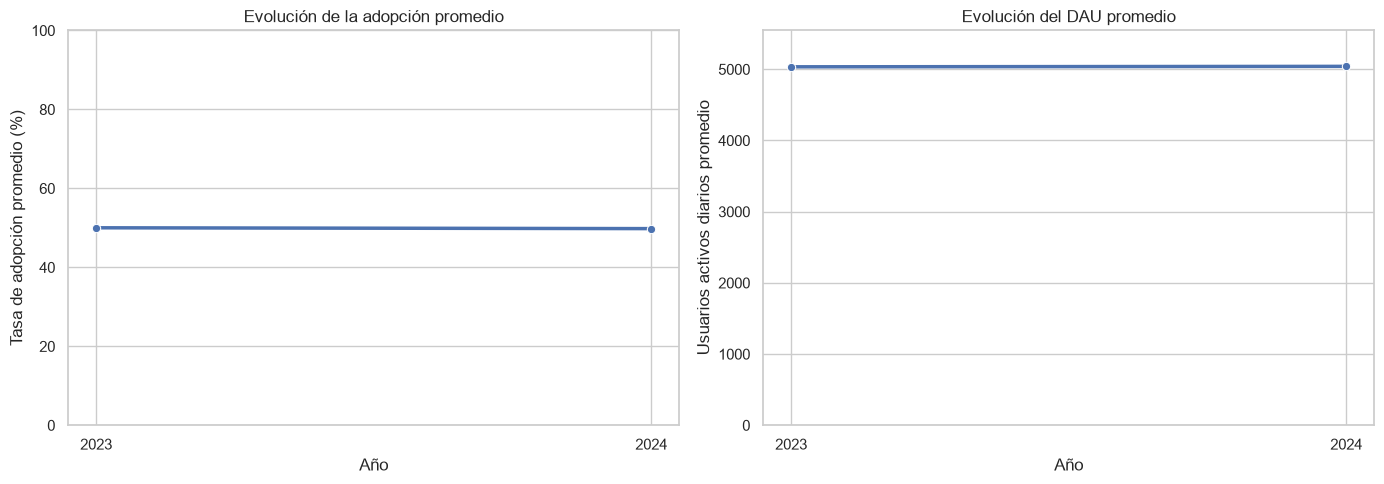

=== EDA 4: Ranking de DAU promedio por herramienta ===
            ai_tool  dau_mean  adoption_rate_mean  sample_size
0            Claude   5063.64               50.20         7286
1              Bard   5061.18               49.81        14519
2        Midjourney   5040.56               49.90        43324
3  Stable Diffusion   5038.88               49.66        21826
4           ChatGPT   5030.00               49.91        58045


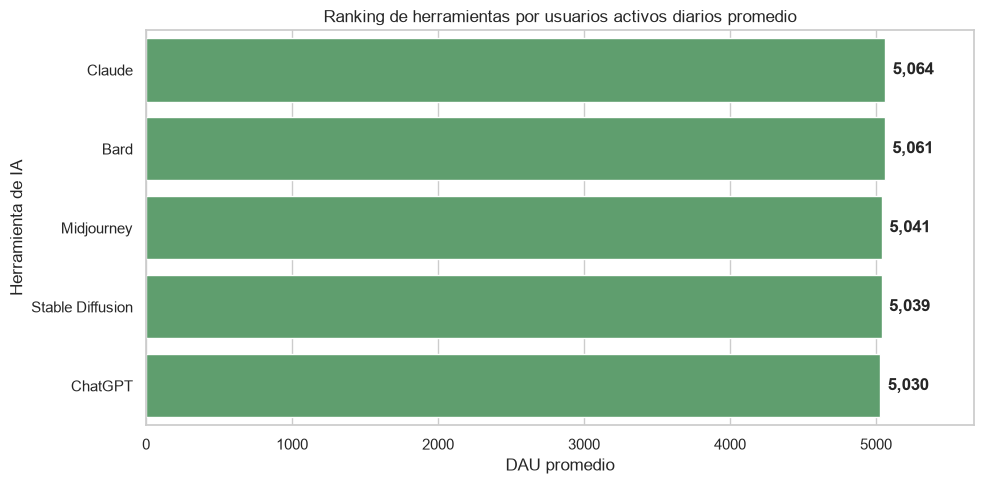

=== KPIs PRINCIPALES ===
                               KPI         Valor                                              Importancia
  Tasa de adopción promedio global        49.87% Resume el nivel general de adopción de IA en la muestra.
  Variación interanual de adopción        -0.42%            Mide el cambio de adopción entre 2023 y 2024.
Mayor DAU promedio por herramienta Claude: 5,064 Identifica la herramienta con mayor uso diario promedio.


In [45]:
# ==========================================
# EDA 3: Evolución anual de adopción y DAU
# ==========================================
annual_metrics = (
    df_clean.groupby('year', observed=True)
    .agg(
        adoption_rate_mean=('adoption_rate', 'mean'),
        dau_mean=('daily_active_users', 'mean'),
        sample_size=('year', 'size'),
    )
    .reset_index()
    .sort_values('year')
)

if len(annual_metrics) < 2:
    raise ValueError('Se requieren al menos dos años para calcular variaciones.')

annual_metrics['adoption_yoy_pct'] = (
    annual_metrics['adoption_rate_mean'].pct_change() * 100
)
annual_metrics['dau_yoy_pct'] = annual_metrics['dau_mean'].pct_change() * 100

print('=== EDA 3: Evolución anual ===')
print(annual_metrics.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=annual_metrics,
    x='year',
    y='adoption_rate_mean',
    marker='o',
    linewidth=2.5,
    ax=axes[0],
)
axes[0].set_title('Evolución de la adopción promedio')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Tasa de adopción promedio (%)')
axes[0].set_xticks(annual_metrics['year'])
axes[0].set_ylim(0, 100)

sns.lineplot(
    data=annual_metrics,
    x='year',
    y='dau_mean',
    marker='o',
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title('Evolución del DAU promedio')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Usuarios activos diarios promedio')
axes[1].set_xticks(annual_metrics['year'])
axes[1].set_ylim(0, annual_metrics['dau_mean'].max() * 1.1)

plt.tight_layout()
plt.show()

# ==========================================
# EDA 4: Ranking de engagement por herramienta
# ==========================================
eda_4 = (
    df_clean.groupby('ai_tool', observed=True)
    .agg(
        dau_mean=('daily_active_users', 'mean'),
        adoption_rate_mean=('adoption_rate', 'mean'),
        sample_size=('ai_tool', 'size'),
    )
    .sort_values('dau_mean', ascending=False)
    .reset_index()
)

print('=== EDA 4: Ranking de DAU promedio por herramienta ===')
print(eda_4.round(2))

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=eda_4,
    x='dau_mean',
    y='ai_tool',
    order=eda_4['ai_tool'].tolist(),
    color='#55A868',
    errorbar=None,
)

for index, value in enumerate(eda_4['dau_mean']):
    ax.text(value + 50, index, f'{value:,.0f}', va='center', fontweight='bold')

ax.set_title('Ranking de herramientas por usuarios activos diarios promedio')
ax.set_xlabel('DAU promedio')
ax.set_ylabel('Herramienta de IA')
ax.set_xlim(0, eda_4['dau_mean'].max() * 1.12)
plt.tight_layout()
plt.show()

# ==========================================
# KPIs principales
# ==========================================
global_adoption_rate = df_clean['adoption_rate'].mean()
adoption_yoy_pct = annual_metrics['adoption_yoy_pct'].iloc[-1]
top_tool = eda_4.iloc[0]

kpis = pd.DataFrame(
    {
        'KPI': [
            'Tasa de adopción promedio global',
            'Variación interanual de adopción',
            'Mayor DAU promedio por herramienta',
        ],
        'Valor': [
            f'{global_adoption_rate:.2f}%',
            f'{adoption_yoy_pct:.2f}%',
            f"{top_tool['ai_tool']}: {top_tool['dau_mean']:,.0f}",
        ],
        'Importancia': [
            'Resume el nivel general de adopción de IA en la muestra.',
            'Mide el cambio de adopción entre 2023 y 2024.',
            'Identifica la herramienta con mayor uso diario promedio.',
        ],
    }
)

print('=== KPIs PRINCIPALES ===')
print(kpis.to_string(index=False))